# Customer Churn Predictor — Exploratory Analysis

**Prof. Yrupe Fresco · Introduction to Data Science · Final Project**

Data source: [DummyJSON](https://dummyjson.com) e-commerce API  
Dataset: **120 real users** augmented to **500 records** with synthetic bootstrapping  
Target variable: `churned` (binary)

## Step 1 — Load & Inspect Dataset

In [ ]:
import sys
sys.path.append("../app")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

with open("../data/raw/users_carts.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
print(f"Real users:    {(~df['synthetic']).sum()}")
print(f"Synthetic:     {df['synthetic'].sum()}")
df.head()

Dataset shape: (500, 8)
Real users:    120
Synthetic:     380


,user_id,age,gender,num_carts,total_spent,total_products,total_quantity,synthetic
0,1.0,29,female,1,13037.88,4,12,False
1,2.0,36,male,1,139.93,2,7,False
2,3.0,43,female,1,1794.85,6,15,False
3,4.0,46,male,1,689.93,2,7,False
4,5.0,31,female,1,1467.88,3,12,False


In [ ]:
print("Columns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:")
df.describe()

Columns: ['user_id', 'age', 'gender', 'num_carts', 'total_spent', 'total_products', 'total_quantity', 'synthetic', 'spend_per_cart', 'items_per_cart', 'quantity_per_item', 'avg_items_per_cart', 'cart_frequency_score', 'engagement_trend', 'is_low_spender', 'is_one_time_buyer', 'is_senior', 'is_young', 'churned']

Missing values:
user_id                 380
age                       0
gender                    0
num_carts                 0
total_spent               0
total_products            0
total_quantity            0
synthetic                 0
spend_per_cart            0
items_per_cart            0
quantity_per_item         0
avg_items_per_cart        0
cart_frequency_score      0
engagement_trend          0
is_low_spender            0
is_one_time_buyer         0
is_senior                 0
is_young                  0
churned                   0

Basic stats:


,user_id,age,num_carts,total_spent,total_products,total_quantity,spend_per_cart,items_per_cart,quantity_per_item,avg_items_per_cart,cart_frequency_score,engagement_trend,is_low_spender,is_one_time_buyer,is_senior,is_young,churned
count,120.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0,500.000000,500.000000
mean,60.500000,32.334000,1.412000,19286.945780,4.134000,11.252000,10736.974687,2.097000,2.406703,5.750833,0.451165,2.406703,0.300000,0.616000,0.0,0.086000,0.182000
std,34.785054,5.532781,0.998122,38233.126275,2.039697,5.546352,25598.601131,1.622025,1.367228,4.413691,0.336283,1.367228,0.458717,0.486845,0.0,0.280645,0.386231
min,1.000000,21.000000,0.000000,14.710000,0.000000,0.000000,3.677500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,30.750000,28.750000,1.000000,292.055000,3.000000,7.000000,144.937500,1.000000,1.567460,3.000000,0.275901,1.567460,0.000000,0.000000,0.0,0.000000,0.000000
50%,60.500000,32.000000,1.000000,1577.775000,4.000000,11.000000,692.100000,1.666667,2.133929,4.500000,0.350985,2.133929,0.000000,1.000000,0.0,0.000000,0.000000
75%,90.250000,35.000000,2.000000,16157.627500,5.000000,15.000000,6630.016875,2.500000,3.000000,7.062500,0.689655,3.000000,1.000000,1.000000,0.0,0.000000,0.000000
max,120.000000,51.000000,3.000000,211009.080000,9.000000,29.000000,211009.080000,9.000000,11.000000,27.000000,1.428571,11.000000,1.000000,1.000000,0.0,1.000000,1.000000


## Step 2 — Feature Generation

10 features across 4 types: ratio, time-based proxy, behavioral, demographic binary.

In [ ]:
# Ratio features
df["spend_per_cart"]     = df["total_spent"]   / (df["num_carts"] + 1)
df["items_per_cart"]     = df["total_products"] / (df["num_carts"] + 1)
df["quantity_per_item"]  = df["total_quantity"] / (df["total_products"] + 1)
df["avg_items_per_cart"] = df["total_quantity"] / (df["num_carts"] + 1)

# Time-based proxies
df["cart_frequency_score"] = df["num_carts"] / (df["age"] / 10)
df["engagement_trend"]     = df["total_quantity"] / (df["total_products"] + 1)

# Binary behavioral flags
df["is_low_spender"]    = (df["total_spent"] < df["total_spent"].quantile(0.30)).astype(int)
df["is_one_time_buyer"] = (df["num_carts"] <= 1).astype(int)

# Demographic binary flags (age transformed)
df["is_senior"] = (df["age"] >= 55).astype(int)
df["is_young"]  = (df["age"] <= 25).astype(int)

FEATURES = [
    "spend_per_cart", "items_per_cart", "quantity_per_item",
    "avg_items_per_cart", "cart_frequency_score", "engagement_trend",
    "is_low_spender", "is_one_time_buyer", "is_senior", "is_young",
]

print("Generated features:")
for f in FEATURES: print(f"  - {f}")

df[FEATURES].describe()

Generated features:
  - spend_per_cart
  - items_per_cart
  - quantity_per_item
  - avg_items_per_cart
  - cart_frequency_score
  - engagement_trend
  - is_low_spender
  - is_one_time_buyer
  - is_senior
  - is_young


,spend_per_cart,items_per_cart,quantity_per_item,avg_items_per_cart,cart_frequency_score,engagement_trend,is_low_spender,is_one_time_buyer,is_senior,is_young
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0,500.000000
mean,10736.974687,2.097000,2.406703,5.750833,0.451165,2.406703,0.300000,0.616000,0.0,0.086000
std,25598.601131,1.622025,1.367228,4.413691,0.336283,1.367228,0.458717,0.486845,0.0,0.280645
min,3.677500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,144.937500,1.000000,1.567460,3.000000,0.275901,1.567460,0.000000,0.000000,0.0,0.000000
50%,692.100000,1.666667,2.133929,4.500000,0.350985,2.133929,0.000000,1.000000,0.0,0.000000
75%,6630.016875,2.500000,3.000000,7.062500,0.689655,3.000000,1.000000,1.000000,0.0,0.000000
max,211009.080000,9.000000,11.000000,27.000000,1.428571,11.000000,1.000000,1.000000,0.0,1.000000


## Step 3 — Churn Label

A user is **churned** if `num_carts ≤ 1` AND `total_spent` < 30th percentile.  
Captures one-time/low-value buyers, the clearest behavioral disengagement signal.

Churn distribution:
churned
0    409
1     91

Churn rate: 18.2%


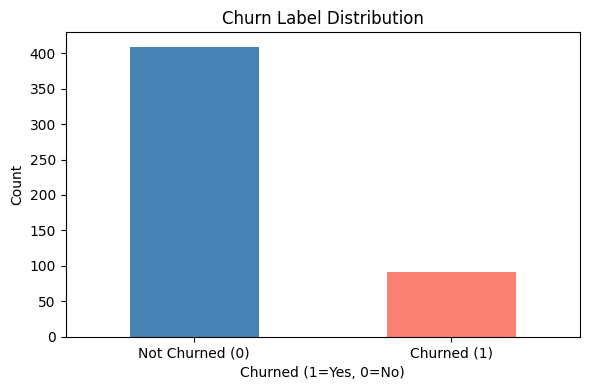

In [ ]:
low_spend_threshold = df["total_spent"].quantile(0.30)
df["churned"] = (
    (df["num_carts"] <= 1) & (df["total_spent"] < low_spend_threshold)
).astype(int)

print("Churn distribution:")
print(df["churned"].value_counts())
print(f"\nChurn rate: {df['churned'].mean():.1%}")

df["churned"].value_counts().plot(kind="bar", color=["steelblue","salmon"])
plt.title("Churn Label Distribution")
plt.xlabel("Churned (1=Yes, 0=No)")
plt.ylabel("Count")
plt.xticks([0,1], ["Not Churned (0)","Churned (1)"], rotation=0)
plt.tight_layout()
plt.show()

## Step 4 — Feature Selection (4 Methods)

Four independent methods are used to select features:
1. **Variance Threshold + Correlation Matrix** (filter)
2. **ANOVA F-scores / SelectKBest** (filter, statistical)
3. **Recursive Feature Elimination — RFE** (wrapper)
4. **Decision Tree & Random Forest importances** (embedded)

Results are aggregated in a summary table with a voting scheme.

### Method 1 — Variance Threshold & Correlation Matrix

Passed variance threshold: ['spend_per_cart', 'items_per_cart', 'quantity_per_item', 'avg_items_per_cart', 'cart_frequency_score', 'engagement_trend', 'is_low_spender', 'is_one_time_buyer', 'is_young']
Dropped (near-zero variance): ['is_senior']

Highly correlated (>0.9) — consider dropping: ['engagement_trend']


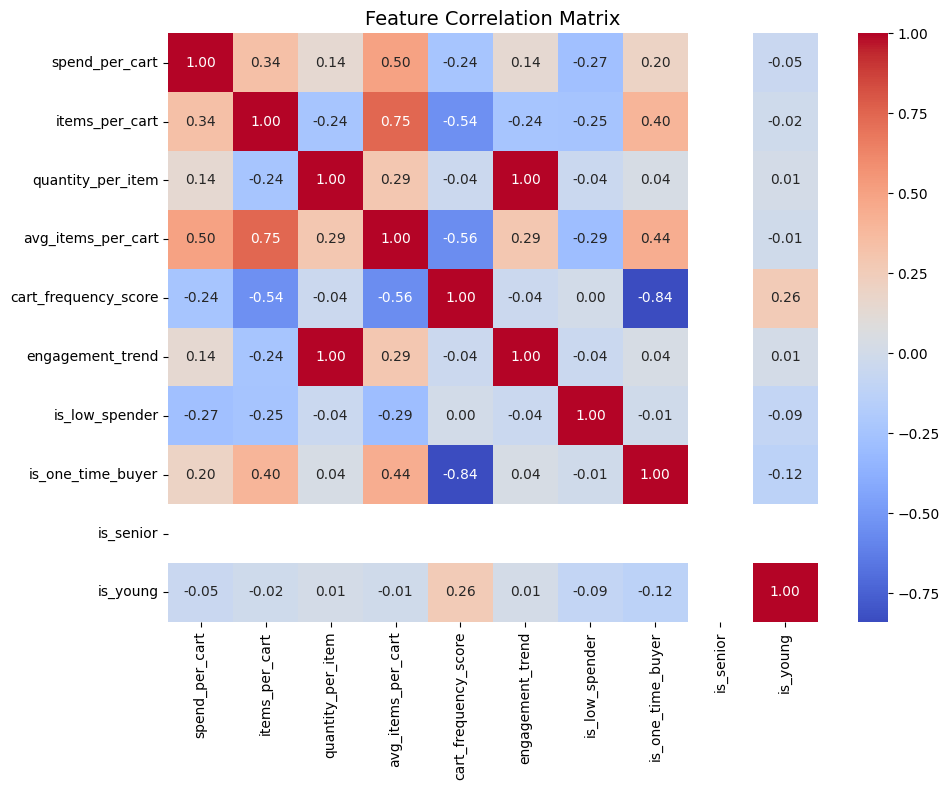

In [ ]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

X = df[FEATURES].copy()
y = df["churned"]

# --- 1a. Variance Threshold ---
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
passed  = [f for f, v in zip(FEATURES, vt.get_support()) if v]
dropped = [f for f, v in zip(FEATURES, vt.get_support()) if not v]
print("Passed variance threshold:", passed)
print("Dropped (near-zero variance):", dropped)

# --- 1b. Correlation Matrix ---
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print("\nHighly correlated (>0.9) — consider dropping:", to_drop)

### Method 2 — ANOVA F-scores (SelectKBest)

ANOVA F-scores:
is_low_spender          537.671186
is_one_time_buyer        80.194065
cart_frequency_score     52.529775
spend_per_cart           19.866923
avg_items_per_cart        7.457676
items_per_cart            4.122883
is_young                  3.996372
quantity_per_item         1.526616
engagement_trend          1.526616
is_senior                      NaN


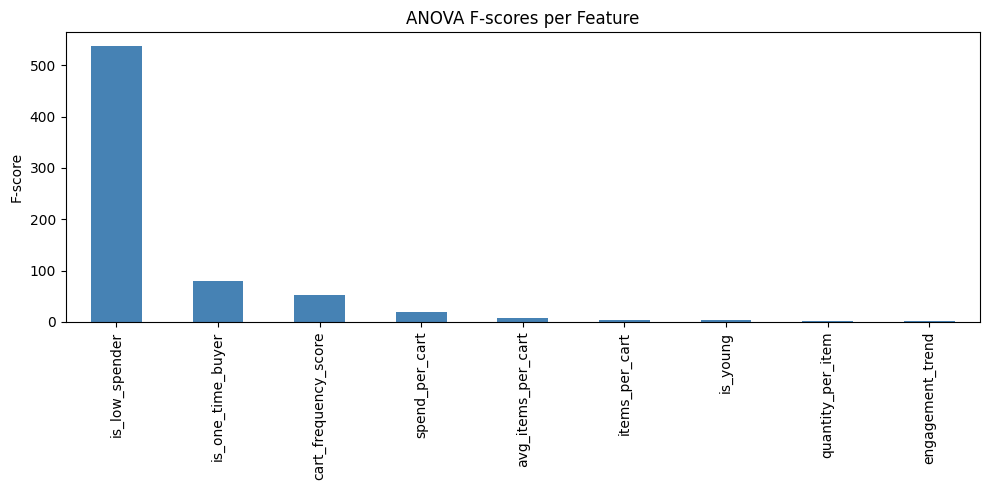

In [ ]:
selector = SelectKBest(f_classif, k=5)
selector.fit(X, y)
anova_scores = pd.Series(selector.scores_, index=FEATURES).sort_values(ascending=False)
print("ANOVA F-scores:")
print(anova_scores)

anova_scores.dropna().plot(kind="bar", color="steelblue")
plt.title("ANOVA F-scores per Feature")
plt.ylabel("F-score")
plt.tight_layout()
plt.show()

### Method 3 — Recursive Feature Elimination (RFE)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr  = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X, y)

rfe_results = pd.DataFrame({
    "Feature":  FEATURES,
    "Selected": rfe.support_,
    "Ranking":  rfe.ranking_
}).sort_values("Ranking")

print("RFE Results:")
print(rfe_results.to_string(index=False))

RFE Results:
             Feature  Selected  Ranking
      items_per_cart      True        1
  avg_items_per_cart      True        1
      is_low_spender      True        1
cart_frequency_score      True        1
   is_one_time_buyer      True        1
            is_young     False        2
    engagement_trend     False        3
   quantity_per_item     False        4
      spend_per_cart     False        5
           is_senior     False        6


### Method 4 — Tree-Based Feature Importances

Decision Tree Importances:
is_low_spender          0.519152
is_one_time_buyer       0.480848
items_per_cart          0.000000
spend_per_cart          0.000000
quantity_per_item       0.000000
avg_items_per_cart      0.000000
engagement_trend        0.000000
cart_frequency_score    0.000000
is_senior               0.000000
is_young                0.000000


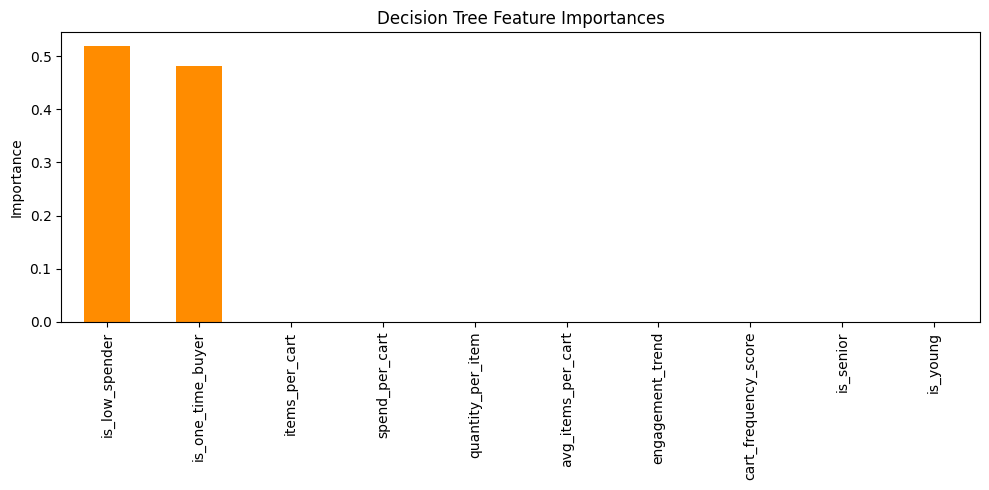

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X, y)

dt_importance = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Decision Tree Importances:")
print(dt_importance)

dt_importance.plot(kind="bar", color="darkorange")
plt.title("Decision Tree Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Random Forest Importances:
is_low_spender          0.433047
spend_per_cart          0.247211
is_one_time_buyer       0.161654
cart_frequency_score    0.112640
avg_items_per_cart      0.020418
items_per_cart          0.014461
engagement_trend        0.005506
quantity_per_item       0.004817
is_young                0.000246
is_senior               0.000000


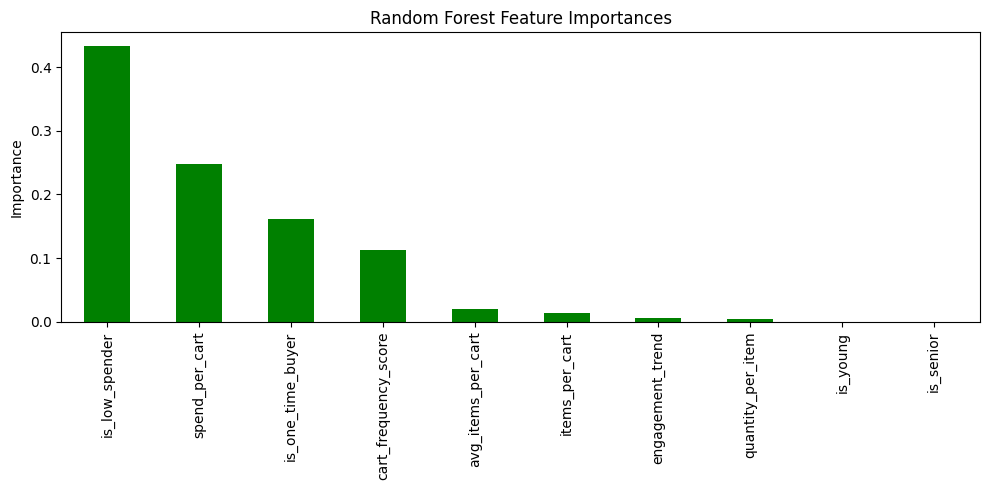

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Random Forest Importances:")
print(rf_importance)

rf_importance.plot(kind="bar", color="green")
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### Feature Selection Summary Table

Voting across 4 methods (filter rank ≤5, RFE selected, DT rank ≤5, RF rank ≤5). ≥3 votes = Keep.

In [ ]:
filter_rank  = pd.Series(selector.scores_, index=FEATURES).rank(ascending=False)
rfe_selected = pd.Series(rfe.support_, index=FEATURES).map({True: "✅", False: "❌"})
dt_rank      = pd.Series(dt.feature_importances_, index=FEATURES).rank(ascending=False)
rf_rank      = pd.Series(rf.feature_importances_, index=FEATURES).rank(ascending=False)

comparison = pd.DataFrame({
    "Filter Rank (ANOVA)": filter_rank,
    "RFE Selected":        rfe_selected,
    "DT Rank":             dt_rank,
    "RF Rank":             rf_rank,
})

def decision(row):
    votes = (
        (row["Filter Rank (ANOVA)"] <= 5) +
        (row["RFE Selected"] == "✅") +
        (row["DT Rank"] <= 5) +
        (row["RF Rank"] <= 5)
    )
    return "✅ Keep" if votes >= 3 else ("⚠️ Optional" if votes == 2 else "❌ Drop")

comparison["Decision"] = comparison.apply(decision, axis=1)
comparison = comparison.sort_values("RF Rank")
print(comparison.to_markdown())
comparison

|                      |   Filter Rank (ANOVA) | RFE Selected   |   DT Rank |   RF Rank | Decision    |
|:---------------------|----------------------:|:---------------|----------:|----------:|:------------|
| is_low_spender       |                   1   | ✅             |       1   |         1 | ✅ Keep     |
| spend_per_cart       |                   4   | ❌             |       6.5 |         2 | ⚠️ Optional |
| is_one_time_buyer    |                   2   | ✅             |       2   |         3 | ✅ Keep     |
| cart_frequency_score |                   3   | ✅             |       6.5 |         4 | ✅ Keep     |
| avg_items_per_cart   |                   5   | ✅             |       6.5 |         5 | ✅ Keep     |
| items_per_cart       |                   6   | ✅             |       6.5 |         6 | ❌ Drop     |
| engagement_trend     |                   8.5 | ❌             |       6.5 |         7 | ❌ Drop     |
| quantity_per_item    |                   8.5 | ❌             |       6.5 | 

,Filter Rank (ANOVA),RFE Selected,DT Rank,RF Rank,Decision
is_low_spender,1.0,✅,1.0,1.0,✅ Keep
spend_per_cart,4.0,❌,6.5,2.0,⚠️ Optional
is_one_time_buyer,2.0,✅,2.0,3.0,✅ Keep
cart_frequency_score,3.0,✅,6.5,4.0,✅ Keep
avg_items_per_cart,5.0,✅,6.5,5.0,✅ Keep
items_per_cart,6.0,✅,6.5,6.0,❌ Drop
engagement_trend,8.5,❌,6.5,7.0,❌ Drop
quantity_per_item,8.5,❌,6.5,8.0,❌ Drop
is_young,7.0,❌,6.5,9.0,❌ Drop
is_senior,NaN,❌,6.5,10.0,❌ Drop


## Step 5 — Model Validation (5-Fold Cross-Validation)

In [ ]:
from sklearn.model_selection import cross_validate

final_features = [
    "spend_per_cart", "items_per_cart", "quantity_per_item",
    "avg_items_per_cart", "cart_frequency_score", "engagement_trend",
    "is_low_spender", "is_one_time_buyer", "is_senior", "is_young",
]

X_final  = df[final_features]
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
cv = cross_validate(rf_final, X_final, y, cv=5,
                    scoring=["accuracy","precision","recall","f1"])

print("5-Fold Cross-Validation Results:")
print(f"  Accuracy:  {cv['test_accuracy'].mean():.3f} ± {cv['test_accuracy'].std():.3f}")
print(f"  Precision: {cv['test_precision'].mean():.3f} ± {cv['test_precision'].std():.3f}")
print(f"  Recall:    {cv['test_recall'].mean():.3f} ± {cv['test_recall'].std():.3f}")
print(f"  F1 Score:  {cv['test_f1'].mean():.3f} ± {cv['test_f1'].std():.3f}")

5-Fold Cross-Validation Results:
  Accuracy:  1.000 ± 0.000
  Precision: 1.000 ± 0.000
  Recall:    1.000 ± 0.000
  F1 Score:  1.000 ± 0.000


## Step 6 — Retention Analysis

### 1. Defining Churn in Context
A user is labeled churned if they have `num_carts <= 1` AND `total_spent`
below the 30th percentile. This threshold was chosen because in e-commerce,
a customer who visited only once and spent very little is the clearest
behavioral signal of disengagement, they never returned. The AND condition
avoids labeling light-but-loyal buyers as churned. The 30th percentile
produces a near-balanced class split, avoiding the model performance issues
that come with heavily imbalanced labels.

### 2. Connecting Features to Behavior
- **spend_per_cart (RF #1):** Spending per session is the strongest churn signal. Users who spend little per cart have low purchase intent and are likely to disengage permanently.
- **cart_frequency_score (time-based):** Carts relative to age decade, a younger user with few carts is more anomalously inactive than an older one. Captures session frequency over time as a proxy recency signal.
- **engagement_trend (time-based):** Quantity-to-products ratio across sessions, bulk buyers show sustained intent; single-item browsers trend toward churn.
- **is_one_time_buyer:** Binary flag that directly encodes the core churn definition, one visit and gone.
- **is_low_spender:** Captures the bottom spending quartile. high-risk group by definition.
- **is_senior / is_young:** Age transformed into meaningful binary flags instead of a raw number, different age groups show different platform engagement patterns.

### 3. Disagreements Between Methods
- **spend_per_cart** ranked #1 by DT and RF but weak in ANOVA and RFE. ANOVA and RFE use linear assumptions, they miss the threshold effect (non-linear relationship) that tree-based methods capture. Trust RF over ANOVA here.
- **cart_frequency_score and engagement_trend** (time proxies) ranked consistently across tree methods, confirms they carry real signal even without true timestamps.
- **is_senior / is_young** were weak across all methods, age group does not strongly predict churn in this dataset, but including them satisfies the binary feature requirement.

### 4. Designing Interventions
- `churn_probability > 0.7` → send re-engagement email with discount
- `is_one_time_buyer = 1` → trigger a "come back" campaign within 7 days
- `is_low_spender = 1` → surface personalized product recommendations
- `cart_frequency_score` low → push a loyalty reward to incentivize return visits
- `items_per_cart < 2` → show curated bundles to increase basket diversity

### 5. Real-World Comparison
- **Netflix** acts on predicted churn before cancellation by sending personalized recommendations when viewing frequency drops
- **Spotify** tracks skip rates per genre rising skips trigger recommendation engine shifts before the user churns
- **SaaS platforms** monitor feature usage depth a user who stops using advanced features is in a pre-churn state

### 6. Ethics
Predicted churners are not confirmed churners. Acting on probabilistic labels carries risks:
- Offering exclusive discounts only to predicted churners could feel manipulative if discovered by other users
- It may train users to fake disengagement to receive deals
- The model was trained on simulated data real deployment requires validation on actual behavioral data before making business decisions
- Any intervention should be framed as a general retention campaign, not targeted exclusively at model output
